In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Example of one subject, one electrode**

In [50]:
df = pd.read_csv("dataset/derivative_mid_5min/sub-001.csv")
df.head()

,Fp1,Fp2,F3,F4,C3,C4,P3,P4,O1,O2,F7,F8,T3,T4,T5,T6,Fz,Cz,Pz
0,28.106768,27.441973,23.673218,19.875109,18.152576,15.297676,18.360073,16.858160,15.213113,22.900726,23.686169,25.682659,22.683741,29.406986,16.644232,19.460236,19.185287,16.738230,17.906288
1,26.727509,26.027483,22.766195,18.799307,17.922928,14.887482,18.263588,17.043249,15.528177,23.191498,23.063129,25.104593,22.456659,28.306454,17.296949,19.315311,18.255154,16.482952,17.974981
2,25.426458,24.821260,21.670372,18.061966,17.749981,14.876583,18.253233,17.359100,15.895592,23.393311,22.509563,24.801735,22.091560,27.072908,17.793692,19.173122,17.506075,16.362591,18.104002
3,24.698235,24.245667,20.612814,17.946365,17.708075,15.343101,18.392147,17.848988,16.297136,23.588772,22.261555,24.921106,21.722656,26.061998,18.111496,19.207611,17.145636,16.513475,18.382906
4,24.880493,24.566380,19.826670,18.596111,17.852354,16.241646,18.706148,18.490246,16.699085,23.836700,22.469017,25.498295,21.471867,25.558849,18.246462,19.519907,17.319199,17.028008,18.853109


In [51]:
df.shape

(150000, 19)

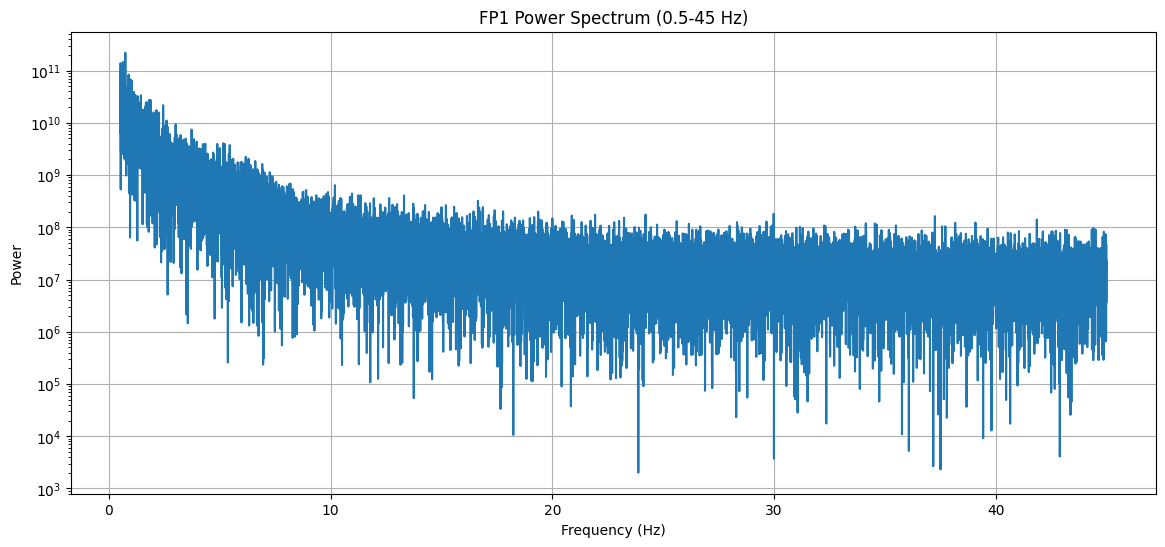

In [52]:
fft = np.fft.fft(df["Fp1"])
frequencies = np.fft.fftfreq(len(df["Fp1"]), 1/500)  # Frequency axis (Fs = 500 Hz)

valid_freqs = (frequencies >= 0.5) & (frequencies <= 45)
frequencies = frequencies[valid_freqs]
fft = fft[valid_freqs]

plt.figure(figsize=(14, 6))
plt.yscale("log")

plt.plot(frequencies, np.abs(fft)**2)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("FP1 Power Spectrum (0.5-45 Hz)")
plt.grid()
plt.show()


In [53]:
BINS = np.array([0.5, 4, 6, 7, 8, 8.5, 9, 9.5, 10, 10.5, 11, 11.5, 12, 12.5, 13, 16, 19, 22, 25, 30, 35, 40, 45])
print("Number of features: " + str(len(BINS)-1))

Number of features: 22


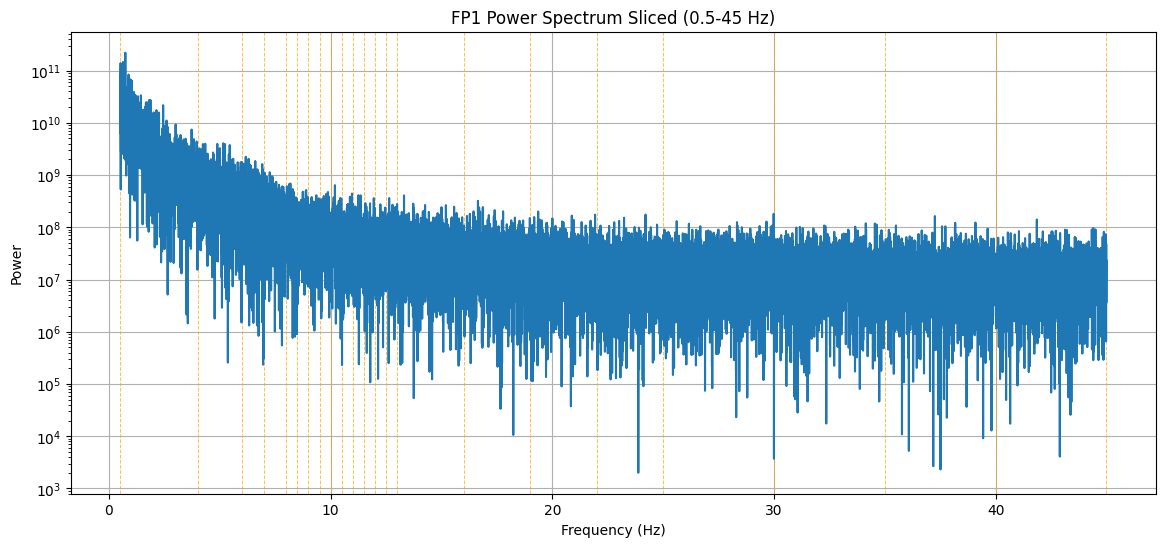

In [54]:
# Truncate arrays to include only 0-50 Hz

plt.figure(figsize=(14, 6))
plt.yscale("log")

for bin_freq in BINS:
    plt.axvline(x=bin_freq, color="orange", linestyle="dashed", linewidth=0.7, alpha=0.7)

plt.plot(frequencies, np.abs(fft)**2)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("FP1 Power Spectrum Sliced (0.5-45 Hz)")
plt.grid()
plt.show()

### Single experimentation

In [55]:
df = pd.read_csv("dataset/derivative_mid_5min/sub-001.csv")

fft = np.fft.fft(df["Fp1"]) 
frequencies = np.fft.fftfreq(len(df["Fp1"]), 1/500)  # Frequency axis (Fs = 500 Hz)

power = np.log10(np.abs(fft)**2)

valid_freqs = (frequencies >= 0.5) & (frequencies <= 45)
frequencies = frequencies[valid_freqs]
fft = fft[valid_freqs]

freq_power = pd.DataFrame([frequencies, power]).T
freq_power.columns = ["Frequency", "Power"]
# Bin the frequency values
freq_power["Bin"] = pd.cut(freq_power["Frequency"], bins=BINS, right=False)

binned_sums = freq_power.groupby("Bin", observed=False)["Power"].sum().reset_index()
binned_sums.columns = ["Bin", "PowerBand_subject001"]


electrode = "FP1"

# Format the bin column 
binned_sums["Electrode_Bin"] = binned_sums["Bin"].apply(lambda x: f"{electrode}_{x.left:.1f}-{x.right:.1f}")
# FP1_00_02 stands for the bin [0.0, 0.2), FP1_100_105 for [10.0, 10.5)

binned_sums = binned_sums[["Electrode_Bin", "PowerBand_subject001"]]

bin_names = binned_sums["Electrode_Bin"].to_numpy()
power_values = binned_sums["PowerBand_subject001"].to_numpy()

# Create a new DataFrame with bins as columns and power values as a single row
pd.DataFrame([power_values], columns=bin_names)

,FP1_0.5-4.0,FP1_4.0-6.0,FP1_6.0-7.0,FP1_7.0-8.0,FP1_8.0-8.5,FP1_8.5-9.0,FP1_9.0-9.5,FP1_9.5-10.0,FP1_10.0-10.5,FP1_10.5-11.0,...,FP1_12.0-12.5,FP1_12.5-13.0,FP1_13.0-16.0,FP1_16.0-19.0,FP1_19.0-22.0,FP1_22.0-25.0,FP1_25.0-30.0,FP1_30.0-35.0,FP1_35.0-40.0,FP1_40.0-45.0
0,9955.750745,5166.757088,2507.778385,2449.495715,1202.876916,1184.860608,1183.854664,1167.250378,1178.04142,1159.252421,...,1140.930186,1135.624669,6690.894483,6591.210605,6450.583919,6361.024333,10586.178526,10564.137144,10451.627789,10400.993879


## Feature Extraction

In [57]:
all_subjects_power_merged = pd.DataFrame()
for i in range(1, 89):
    subject_power_merged = pd.DataFrame()
    if i < 10:
        df = pd.read_csv(f"dataset/derivative_mid_5min/sub-00{i}.csv")
    else:
        df = pd.read_csv(f"dataset/derivative_mid_5min/sub-0{i}.csv")

    for electrode in df.columns:
        fft = np.fft.fft(df[electrode])
        power = np.log10(np.abs(fft)**2)
        frequencies = np.fft.fftfreq(len(df[electrode]), 1/500)  # Frequency axis (Fs = 500 Hz)
        
        valid_freqs = (frequencies >= 0.5) & (frequencies <= 45)
        frequencies = frequencies[valid_freqs]
        fft = fft[valid_freqs]

        freq_power = pd.DataFrame([frequencies, power]).T
        freq_power.columns = ["Frequency", "Power"]
        freq_power["Bin"] = pd.cut(freq_power["Frequency"], bins=BINS, right=False)

        # Sum the Power values (magnitude) within each bin
        binned_sums = freq_power.groupby("Bin", observed=False)["Power"].sum().reset_index()

        subject_id = f"subject_00{i}" if i < 10 else f"subject_0{i}"
        binned_sums.columns = ["Bin", subject_id]

        # Format the bin column, FP1_0.0-0.2 stands for the bin [0.0, 0.2), FP1_10.0-10.5 for [10.0, 10.5)
        binned_sums["Subject"] = binned_sums["Bin"].apply(lambda x: f"{electrode}_{x.left:.1f}-{x.right:.1f}")
        
        binned_sums = binned_sums[["Subject", subject_id]]# Drop the original Bin column

        bin_names = binned_sums["Subject"].to_numpy()
        power_values = binned_sums[subject_id].to_numpy()
        # a new DataFrame with bins as columns and power values as a single row
        subject_data = pd.DataFrame([power_values], columns=bin_names)

        subject_power_merged = pd.concat([subject_power_merged, subject_data], axis=1)
   
    all_subjects_power_merged = pd.concat([all_subjects_power_merged, subject_power_merged], axis=0)
    print(str(i)+"/88")

1/88
2/88
3/88
4/88
5/88
6/88
7/88
8/88
9/88
10/88
11/88
12/88
13/88
14/88
15/88
16/88
17/88
18/88
19/88
20/88
21/88
22/88
23/88
24/88
25/88
26/88
27/88
28/88
29/88
30/88
31/88
32/88
33/88
34/88
35/88
36/88
37/88
38/88
39/88
40/88
41/88
42/88
43/88
44/88
45/88
46/88
47/88
48/88
49/88
50/88
51/88
52/88
53/88
54/88
55/88
56/88
57/88
58/88
59/88
60/88
61/88
62/88
63/88
64/88
65/88
66/88
67/88
68/88
69/88
70/88
71/88
72/88
73/88
74/88
75/88
76/88
77/88
78/88
79/88
80/88
81/88
82/88
83/88
84/88
85/88
86/88
87/88
88/88


In [58]:
all_subjects_power_merged.head()

,Fp1_0.5-4.0,Fp1_4.0-6.0,Fp1_6.0-7.0,Fp1_7.0-8.0,Fp1_8.0-8.5,Fp1_8.5-9.0,Fp1_9.0-9.5,Fp1_9.5-10.0,Fp1_10.0-10.5,Fp1_10.5-11.0,...,Pz_12.0-12.5,Pz_12.5-13.0,Pz_13.0-16.0,Pz_16.0-19.0,Pz_19.0-22.0,Pz_22.0-25.0,Pz_25.0-30.0,Pz_30.0-35.0,Pz_35.0-40.0,Pz_40.0-45.0
0,9955.750745,5166.757088,2507.778385,2449.495715,1202.876916,1184.860608,1183.854664,1167.250378,1178.041420,1159.252421,...,1132.143466,1119.875162,6589.767521,6412.512109,6286.990793,6179.468825,10068.675832,9878.417509,9668.294168,9468.609676
0,9864.894481,5083.001367,2453.252246,2442.859465,1244.061575,1284.567749,1282.557433,1197.275956,1181.885387,1170.067091,...,1142.437048,1131.845351,6713.797219,6622.897761,6460.066609,6305.227792,10213.447614,9910.906189,9574.629415,9462.328771
0,9856.737590,5159.567932,2535.202948,2529.867863,1252.632394,1296.274698,1286.857729,1272.269901,1229.664138,1201.065838,...,1140.883886,1140.975407,6649.246749,6506.370354,6348.642294,6201.893567,10178.596795,9871.239323,9613.606824,9397.156895
0,9936.305097,5088.568334,2464.652298,2435.856546,1190.249093,1181.555355,1172.359629,1158.801993,1146.683389,1150.298984,...,1118.710524,1118.960536,6559.930590,6441.948500,6271.595351,6170.692211,10081.682010,9934.645521,9869.659768,9800.931541
0,9991.969761,5124.068579,2459.935883,2449.938167,1200.562400,1204.158331,1181.841324,1177.254748,1169.137706,1169.725510,...,1144.131702,1139.105803,6684.932046,6528.548587,6376.709055,6277.370892,10260.694404,10076.816840,9959.135854,10055.388244


In [59]:
subject_ids = [f"subject_{i:03d}" for i in range(1, 89)] 
all_subjects_power_merged.index = subject_ids
all_subjects_power_merged.head()

,Fp1_0.5-4.0,Fp1_4.0-6.0,Fp1_6.0-7.0,Fp1_7.0-8.0,Fp1_8.0-8.5,Fp1_8.5-9.0,Fp1_9.0-9.5,Fp1_9.5-10.0,Fp1_10.0-10.5,Fp1_10.5-11.0,...,Pz_12.0-12.5,Pz_12.5-13.0,Pz_13.0-16.0,Pz_16.0-19.0,Pz_19.0-22.0,Pz_22.0-25.0,Pz_25.0-30.0,Pz_30.0-35.0,Pz_35.0-40.0,Pz_40.0-45.0
subject_001,9955.750745,5166.757088,2507.778385,2449.495715,1202.876916,1184.860608,1183.854664,1167.250378,1178.041420,1159.252421,...,1132.143466,1119.875162,6589.767521,6412.512109,6286.990793,6179.468825,10068.675832,9878.417509,9668.294168,9468.609676
subject_002,9864.894481,5083.001367,2453.252246,2442.859465,1244.061575,1284.567749,1282.557433,1197.275956,1181.885387,1170.067091,...,1142.437048,1131.845351,6713.797219,6622.897761,6460.066609,6305.227792,10213.447614,9910.906189,9574.629415,9462.328771
subject_003,9856.737590,5159.567932,2535.202948,2529.867863,1252.632394,1296.274698,1286.857729,1272.269901,1229.664138,1201.065838,...,1140.883886,1140.975407,6649.246749,6506.370354,6348.642294,6201.893567,10178.596795,9871.239323,9613.606824,9397.156895
subject_004,9936.305097,5088.568334,2464.652298,2435.856546,1190.249093,1181.555355,1172.359629,1158.801993,1146.683389,1150.298984,...,1118.710524,1118.960536,6559.930590,6441.948500,6271.595351,6170.692211,10081.682010,9934.645521,9869.659768,9800.931541
subject_005,9991.969761,5124.068579,2459.935883,2449.938167,1200.562400,1204.158331,1181.841324,1177.254748,1169.137706,1169.725510,...,1144.131702,1139.105803,6684.932046,6528.548587,6376.709055,6277.370892,10260.694404,10076.816840,9959.135854,10055.388244


In [60]:
all_subjects_power_merged.columns = pd.MultiIndex.from_tuples(
    [(col.split('_')[0], col.split('_')[1]) for col in all_subjects_power_merged.columns], 
    names=["Electrode", "Frequency Band"]
)

In [61]:
all_subjects_power_merged.head()

Electrode               Fp1                                         \
Frequency Band      0.5-4.0      4.0-6.0      6.0-7.0      7.0-8.0   
subject_001     9955.750745  5166.757088  2507.778385  2449.495715   
subject_002     9864.894481  5083.001367  2453.252246  2442.859465   
subject_003     9856.737590  5159.567932  2535.202948  2529.867863   
subject_004     9936.305097  5088.568334  2464.652298  2435.856546   
subject_005     9991.969761  5124.068579  2459.935883  2449.938167   

Electrode                                                           \
Frequency Band      8.0-8.5      8.5-9.0      9.0-9.5     9.5-10.0   
subject_001     1202.876916  1184.860608  1183.854664  1167.250378   
subject_002     1244.061575  1284.567749  1282.557433  1197.275956   
subject_003     1252.632394  1296.274698  1286.857729  1272.269901   
subject_004     1190.249093  1181.555355  1172.359629  1158.801993   
subject_005     1200.562400  1204.158331  1181.841324  1177.254748   

Electrode                                 ...           Pz               \
Frequency Band    10.0-10.5    10.5-11.0  ...    12.0-12.5    12.5-13.0   
subject_001     1178.041420  1159.252421  ...  1132.143466  1119.875162   
subject_002     1181.885387  1170.067091  ...  1142.437048  1131.845351   
subject_003     1229.664138  1201.065838  ...  1140.883886  1140.975407   
subject_004     1146.683389  1150.298984  ...  1118.710524  1118.960536   
subject_005     1169.137706  1169.725510  ...  1144.131702  1139.105803   

Electrode                                                           \
Frequency Band    13.0-16.0    16.0-19.0    19.0-22.0    22.0-25.0   
subject_001     6589.767521  6412.512109  6286.990793  6179.468825   
subject_002     6713.797219  6622.897761  6460.066609  6305.227792   
subject_003     6649.246749  6506.370354  6348.642294  6201.893567   
subject_004     6559.930590  6441.948500  6271.595351  6170.692211   
subject_005     6684.932046  6528.548587  6376.709055  6277.370892   

Electrode                                                              
Frequency Band     25.0-30.0     30.0-35.0    35.0-40.0     40.0-45.0  
subject_001     10068.675832   9878.417509  9668.294168   9468.609676  
subject_002     10213.447614   9910.906189  9574.629415   9462.328771  
subject_003     10178.596795   9871.239323  9613.606824   9397.156895  
subject_004     10081.682010   9934.645521  9869.659768   9800.931541  
subject_005     10260.694404  10076.816840  9959.135854  10055.388244  

[5 rows x 418 columns]

In [62]:
all_subjects_power_merged.to_csv("./dataset/PSDfeature_log.csv",index=True)